In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")


Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/equipment_district_hospital.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset loaded successfully!
Rows: 10000
Columns: 34


In [3]:
df.head()

,id,facility_level,facility_id,region_type,has_biomedical_engineer,has_maintenance_workshop,has_maintenance_budget,has_equipment_inventory,power_source,voltage_stabilizer,...,spare_parts_available,service_contract_active,user_manual_available,staff_trained_on_equipment,repair_attempted,repair_successful,decommissioned,services_disrupted,patients_referred_equipment_down,annual_maintenance_cost_usd
0,1,district_hospital,EQP_0018,peri_urban,0,0,0,0,none,0,...,0,0,1,0,0,0,0,0,0,546.0
1,2,district_hospital,EQP_0014,rural,0,0,0,1,grid_unreliable,0,...,0,0,0,0,0,0,0,0,0,1522.0
2,3,district_hospital,EQP_0153,rural,0,0,0,0,grid_unreliable,1,...,1,0,0,0,0,0,0,0,0,1852.0
3,4,district_hospital,EQP_0019,peri_urban,0,0,0,0,none,0,...,0,0,0,1,1,0,0,1,1,251.0
4,5,district_hospital,EQP_0187,rural,0,0,0,0,grid_unreliable,1,...,0,0,0,1,0,0,0,0,0,124.0


In [4]:
print("Total columns:", len(df.columns))

for i, col in enumerate(df.columns, 1):
    print(i, "-", col)

Total columns: 34
1 - id
2 - facility_level
3 - facility_id
4 - region_type
5 - has_biomedical_engineer
6 - has_maintenance_workshop
7 - has_maintenance_budget
8 - has_equipment_inventory
9 - power_source
10 - voltage_stabilizer
11 - equipment_type
12 - department
13 - replacement_cost_usd
14 - expected_lifespan_years
15 - equipment_age_years
16 - beyond_lifespan
17 - donated_equipment
18 - year
19 - quarter
20 - currently_functional
21 - failure_in_last_6m
22 - failure_cause
23 - downtime_days_last_6m
24 - preventive_maintenance_done
25 - spare_parts_available
26 - service_contract_active
27 - user_manual_available
28 - staff_trained_on_equipment
29 - repair_attempted
30 - repair_successful
31 - decommissioned
32 - services_disrupted
33 - patients_referred_equipment_down
34 - annual_maintenance_cost_usd


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id                                10000 non-null  int64  
 1   facility_level                    10000 non-null  str    
 2   facility_id                       10000 non-null  str    
 3   region_type                       10000 non-null  str    
 4   has_biomedical_engineer           10000 non-null  int64  
 5   has_maintenance_workshop          10000 non-null  int64  
 6   has_maintenance_budget            10000 non-null  int64  
 7   has_equipment_inventory           10000 non-null  int64  
 8   power_source                      10000 non-null  str    
 9   voltage_stabilizer                10000 non-null  int64  
 10  equipment_type                    10000 non-null  str    
 11  department                        10000 non-null  str    
 12  replacement_cost

In [6]:
missing = df.isnull().sum()

print("Columns with missing values:")
print(missing[missing > 0])

Columns with missing values:
Series([], dtype: int64)


In [7]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [8]:
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

1. id
2. facility_level
3. facility_id
4. region_type
5. has_biomedical_engineer
6. has_maintenance_workshop
7. has_maintenance_budget
8. has_equipment_inventory
9. power_source
10. voltage_stabilizer
11. equipment_type
12. department
13. replacement_cost_usd
14. expected_lifespan_years
15. equipment_age_years
16. beyond_lifespan
17. donated_equipment
18. year
19. quarter
20. currently_functional
21. failure_in_last_6m
22. failure_cause
23. downtime_days_last_6m
24. preventive_maintenance_done
25. spare_parts_available
26. service_contract_active
27. user_manual_available
28. staff_trained_on_equipment
29. repair_attempted
30. repair_successful
31. decommissioned
32. services_disrupted
33. patients_referred_equipment_down
34. annual_maintenance_cost_usd


In [9]:
important_cols = [
    "equipment_type",
    "department",
    "currently_functional",
    "failure_in_last_6m",
    "downtime_days_last_6m",
    "services_disrupted",
    "patients_referred_equipment_down",
    "repair_attempted",
    "repair_successful",
    "spare_parts_available"
]

df[important_cols].head(10)

,equipment_type,department,currently_functional,failure_in_last_6m,downtime_days_last_6m,services_disrupted,patients_referred_equipment_down,repair_attempted,repair_successful,spare_parts_available
0,patient_monitor,critical_care,0,1,12,0,0,0,0,0
1,ventilator,critical_care,0,1,20,0,0,0,0,0
2,anaesthesia_machine,surgical,0,1,12,0,0,0,0,1
3,surgical_diathermy,surgical,0,1,23,1,1,1,0,0
4,autoclave_sterilizer,sterilization,0,1,35,0,0,0,0,0
5,xray_machine,imaging,0,1,28,0,0,0,0,1
6,ultrasound_portable,imaging,0,1,14,0,0,0,0,1
7,CT_scanner,imaging,0,1,67,0,0,0,0,0
8,laboratory_centrifuge,laboratory,1,0,0,0,0,0,0,0
9,haematology_analyzer,laboratory,0,1,54,0,0,0,0,0


In [10]:
print("Currently Functional:")
print(df["currently_functional"].value_counts())

print("\nFailure in Last 6 Months:")
print(df["failure_in_last_6m"].value_counts())

print("\nServices Disrupted:")
print(df["services_disrupted"].value_counts())

Currently Functional:
currently_functional
0    8030
1    1970
Name: count, dtype: int64

Failure in Last 6 Months:
failure_in_last_6m
1    8584
0    1416
Name: count, dtype: int64

Services Disrupted:
services_disrupted
0    7186
1    2814
Name: count, dtype: int64


In [11]:
print("Total patients referred due to equipment downtime:",
      df["patients_referred_equipment_down"].sum())

print("Average patients affected:",
      df["patients_referred_equipment_down"].mean())

print("Maximum patients affected in one record:",
      df["patients_referred_equipment_down"].max())

print("Total service disruption records:",
      df["services_disrupted"].sum())

Total patients referred due to equipment downtime: 12261
Average patients affected: 1.2261
Maximum patients affected in one record: 37
Total service disruption records: 2814


In [12]:
print("Average downtime:",
      df["downtime_days_last_6m"].mean(), "days")

print("Maximum downtime:",
      df["downtime_days_last_6m"].max(), "days")

print("\nDowntime statistics:")
print(df["downtime_days_last_6m"].describe())

Average downtime: 25.0089 days
Maximum downtime: 180 days

Downtime statistics:
count    10000.000000
mean        25.008900
std         30.572623
min          0.000000
25%          2.000000
50%         15.000000
75%         36.000000
max        180.000000
Name: downtime_days_last_6m, dtype: float64


In [13]:
department_impact = (
    df.groupby("department")
      .agg(
          equipment_count=("id", "count"),
          avg_downtime=("downtime_days_last_6m", "mean"),
          service_disruptions=("services_disrupted", "sum"),
          patients_affected=("patients_referred_equipment_down", "sum")
      )
      .sort_values("patients_affected", ascending=False)
)

department_impact

,equipment_count,avg_downtime,service_disruptions,patients_affected
department,,,,
surgical,1500,25.284000,597,2576
critical_care,1000,24.221000,387,1640
laboratory,1500,23.314667,357,1611
imaging,1500,25.498000,347,1475
neonatal,1000,24.990000,231,1112
emergency,500,22.452000,184,887
cardiology,500,27.472000,134,578
sterilization,500,25.668000,120,526
respiratory,500,27.522000,124,515


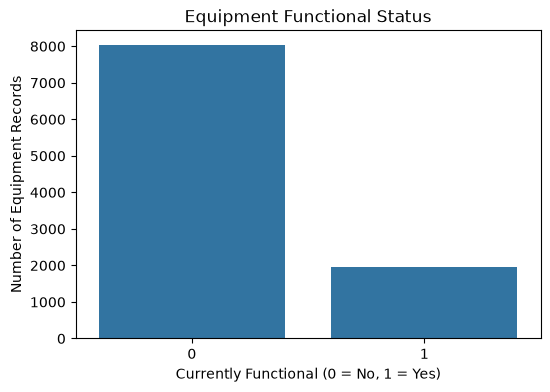

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x="currently_functional", data=df)

plt.title("Equipment Functional Status")
plt.xlabel("Currently Functional (0 = No, 1 = Yes)")
plt.ylabel("Number of Equipment Records")

plt.show()

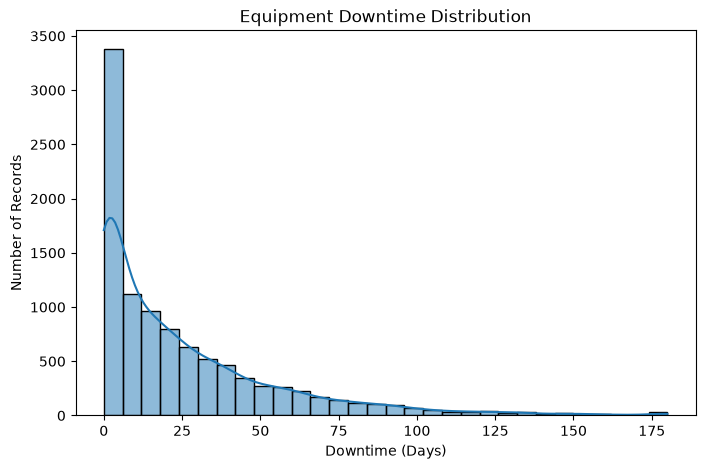

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["downtime_days_last_6m"],
    bins=30,
    kde=True
)

plt.title("Equipment Downtime Distribution")
plt.xlabel("Downtime (Days)")
plt.ylabel("Number of Records")

plt.show()

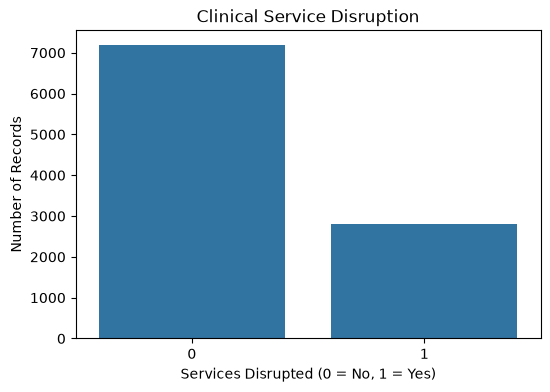

In [16]:
plt.figure(figsize=(6,4))

sns.countplot(x="services_disrupted", data=df)

plt.title("Clinical Service Disruption")
plt.xlabel("Services Disrupted (0 = No, 1 = Yes)")
plt.ylabel("Number of Records")

plt.show()

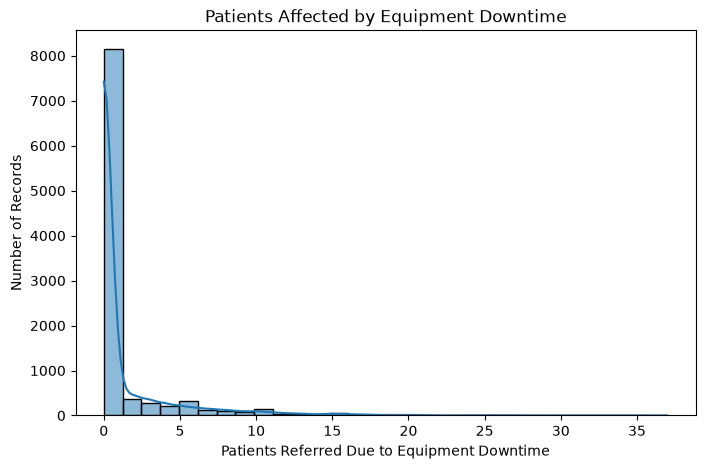

In [17]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["patients_referred_equipment_down"],
    bins=30,
    kde=True
)

plt.title("Patients Affected by Equipment Downtime")
plt.xlabel("Patients Referred Due to Equipment Downtime")
plt.ylabel("Number of Records")

plt.show()

In [18]:
impact_analysis = df.groupby("services_disrupted").agg(
    avg_downtime=("downtime_days_last_6m", "mean"),
    avg_patients_affected=("patients_referred_equipment_down", "mean"),
    total_patients_affected=("patients_referred_equipment_down", "sum"),
    equipment_count=("id", "count")
)

impact_analysis

,avg_downtime,avg_patients_affected,total_patients_affected,equipment_count
services_disrupted,,,,
0,22.751322,0.000000,0,7186
1,30.773987,4.357143,12261,2814


In [19]:
# Compare downtime with patient impact

df["downtime_days_last_6m"].corr(
    df["patients_referred_equipment_down"]
)

np.float64(0.07343627875381278)

In [20]:
high_impact_cases = df[
    (df["services_disrupted"] == 1) &
    (df["patients_referred_equipment_down"] > 0)
]

print("High-impact records:", len(high_impact_cases))

high_impact_cases[
    [
        "equipment_type",
        "department",
        "downtime_days_last_6m",
        "services_disrupted",
        "patients_referred_equipment_down"
    ]
].sort_values(
    "patients_referred_equipment_down",
    ascending=False
).head(10)

High-impact records: 2287


,equipment_type,department,downtime_days_last_6m,services_disrupted,patients_referred_equipment_down
37,blood_bank_refrigerator,blood_bank,64,1,37
8951,GeneXpert,molecular_dx,1,1,34
7326,ultrasound_portable,imaging,24,1,33
8624,autoclave_sterilizer,sterilization,61,1,32
5917,blood_bank_refrigerator,blood_bank,2,1,32
542,anaesthesia_machine,surgical,17,1,31
2974,defibrillator,emergency,10,1,29
6060,patient_monitor,critical_care,49,1,27
710,chemistry_analyzer,laboratory,28,1,27
8054,defibrillator,emergency,2,1,27


In [21]:
# BASELINE: priority based only on downtime

df["baseline_priority"] = (
    df["downtime_days_last_6m"] /
    df["downtime_days_last_6m"].max()
) * 100

df[
    [
        "equipment_type",
        "department",
        "downtime_days_last_6m",
        "baseline_priority"
    ]
].sort_values(
    "baseline_priority",
    ascending=False
).head(10)

,equipment_type,department,downtime_days_last_6m,baseline_priority
1515,infant_warmer,neonatal,180,100.0
9802,anaesthesia_machine,surgical,180,100.0
1471,GeneXpert,molecular_dx,180,100.0
9809,haematology_analyzer,laboratory,180,100.0
1717,blood_bank_refrigerator,blood_bank,180,100.0
1563,surgical_diathermy,surgical,180,100.0
907,CT_scanner,imaging,180,100.0
3171,GeneXpert,molecular_dx,180,100.0
3935,infant_warmer,neonatal,180,100.0
8741,ventilator,critical_care,180,100.0


In [22]:
# Normalize downtime
df["downtime_score"] = (
    df["downtime_days_last_6m"] /
    df["downtime_days_last_6m"].max()
) * 100

# Patient impact
df["patient_impact_score"] = (
    df["patients_referred_equipment_down"] /
    df["patients_referred_equipment_down"].max()
) * 100

# Service disruption
df["service_impact_score"] = (
    df["services_disrupted"] * 100
)

# Equipment currently unavailable
df["availability_score"] = (
    1 - df["currently_functional"]
) * 100

In [23]:
df["clinical_impact_score"] = (
    0.30 * df["downtime_score"] +
    0.25 * df["patient_impact_score"] +
    0.25 * df["service_impact_score"] +
    0.20 * df["availability_score"]
)

In [24]:
def priority_level(score):
    if score >= 70:
        return "HIGH"
    elif score >= 40:
        return "MEDIUM"
    else:
        return "LOW"

df["priority"] = df["clinical_impact_score"].apply(priority_level)

df["priority"].value_counts()

priority
LOW       7065
MEDIUM    2870
HIGH        65
Name: count, dtype: int64

In [25]:
top_priority = df[
    [
        "equipment_type",
        "department",
        "currently_functional",
        "downtime_days_last_6m",
        "services_disrupted",
        "patients_referred_equipment_down",
        "baseline_priority",
        "clinical_impact_score",
        "priority"
    ]
].sort_values(
    "clinical_impact_score",
    ascending=False
)

top_priority.head(15)

,equipment_type,department,currently_functional,downtime_days_last_6m,services_disrupted,patients_referred_equipment_down,baseline_priority,clinical_impact_score,priority
4187,CT_scanner,imaging,0,180,1,20,100.000000,88.513514,HIGH
9510,chemistry_analyzer,laboratory,0,134,1,20,74.444444,80.846847,HIGH
37,blood_bank_refrigerator,blood_bank,0,64,1,37,35.555556,80.666667,HIGH
8185,xray_machine,imaging,0,149,1,16,82.777778,80.644144,HIGH
7805,xray_machine,imaging,0,157,1,14,87.222222,80.626126,HIGH
5904,autoclave_sterilizer,sterilization,0,180,1,8,100.000000,80.405405,HIGH
5061,ventilator,critical_care,0,177,1,8,98.333333,79.905405,HIGH
6501,ventilator,critical_care,0,180,1,7,100.000000,79.729730,HIGH
3256,phototherapy_unit,neonatal,0,115,1,20,63.888889,77.680180,HIGH
9073,suction_machine,surgical,0,134,1,15,74.444444,77.468468,HIGH
